In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
class DIV2KDataset(Dataset):
    def __init__(self, hr_dir, scale=2):
        self.hr_dir = hr_dir
        self.scale = scale
        self.images = sorted(os.listdir(hr_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        hr_path = os.path.join(self.hr_dir, img_name)

        hr = cv2.imread(hr_path)

        # If image is unreadable, skip safely
        if hr is None:
            # return a dummy sample by moving to next index
            return self.__getitem__((idx + 1) % len(self.images))

        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)
        hr = cv2.resize(hr, (256, 256))

        lr = cv2.resize(
            hr,
            (256 // self.scale, 256 // self.scale),
            interpolation=cv2.INTER_CUBIC
        )

        hr = torch.tensor(hr).permute(2,0,1).float() / 255.0
        lr = torch.tensor(lr).permute(2,0,1).float() / 255.0

        return lr, hr

In [6]:
# HR dataset paths (ONLY these two)
train_hr_path = "/kaggle/input/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR"
valid_hr_path = "/kaggle/input/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR"
train_dataset = DIV2KDataset(train_hr_path, scale=2)
valid_dataset = DIV2KDataset(valid_hr_path, scale=2)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

Train samples: 800
Valid samples: 100


In [7]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.ReLU(),
            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 3, 5, padding=2)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class FSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Conv2d(3, 56, 5, padding=2)
        self.shrink = nn.Conv2d(56, 12, 1)
        self.expand = nn.Conv2d(12, 56, 1)
        self.deconv = nn.ConvTranspose2d(56, 3, 9, stride=2, padding=4, output_padding=1)

    def forward(self, x):
        x = torch.relu(self.feature(x))
        x = torch.relu(self.shrink(x))
        x = torch.relu(self.expand(x))
        return self.deconv(x)

In [9]:
class ESPCN(nn.Module):
    def __init__(self, scale=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3 * scale * scale, 3, padding=1),
            nn.PixelShuffle(scale)
        )

    def forward(self, x):
        return self.net(x)

In [10]:
class UNetSR(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.dec1 = nn.Conv2d(128, 64, 3, padding=1)
        self.dec2 = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(e1))
        d1 = torch.relu(self.dec1(e2))
        return self.dec2(d1)

In [11]:
def train_model(model, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0
        for lr, hr in train_loader:
            lr, hr = lr.to(device), hr.to(device)

            sr = model(lr)

            # 🔑 FIX SIZE MISMATCH
            if sr.shape != hr.shape:
                hr = torch.nn.functional.interpolate(
                    hr, size=sr.shape[-2:], mode="bilinear", align_corners=False
                )

            loss = criterion(sr, hr)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

In [12]:
model_srcnn = SRCNN()
model_fsrcnn = FSRCNN()
model_espcn = ESPCN()
model_unet = UNetSR()

train_model(model_srcnn)
train_model(model_fsrcnn)
train_model(model_espcn)
train_model(model_unet)

Epoch 1, Loss: 0.0310
Epoch 2, Loss: 0.0057
Epoch 3, Loss: 0.0026
Epoch 4, Loss: 0.0017
Epoch 5, Loss: 0.0014
Epoch 1, Loss: 0.1186
Epoch 2, Loss: 0.0291
Epoch 3, Loss: 0.0199
Epoch 4, Loss: 0.0156
Epoch 5, Loss: 0.0131
Epoch 1, Loss: 0.0730
Epoch 2, Loss: 0.0176
Epoch 3, Loss: 0.0114
Epoch 4, Loss: 0.0094
Epoch 5, Loss: 0.0084
Epoch 1, Loss: 0.0366
Epoch 2, Loss: 0.0040
Epoch 3, Loss: 0.0013
Epoch 4, Loss: 0.0007
Epoch 5, Loss: 0.0005


In [13]:
def evaluate_model(model, dataset, n=10):
    model.eval()
    psnr_scores, ssim_scores = [], []

    n = min(n, len(dataset))  # safety

    for i in range(n):
        lr, hr = dataset[i]

        lr = lr.unsqueeze(0).to(device)
        hr = hr.permute(1,2,0).numpy()

        with torch.no_grad():
            sr = model(lr)[0].permute(1,2,0).cpu().numpy()

        # Handle size mismatch (VERY IMPORTANT)
        if sr.shape != hr.shape:
            hr = cv2.resize(hr, (sr.shape[1], sr.shape[0]))

        psnr_scores.append(psnr(hr, sr, data_range=1.0))
        ssim_scores.append(ssim(hr, sr, channel_axis=2, data_range=1.0))

    return np.mean(psnr_scores), np.mean(ssim_scores)

In [14]:
def model_size_mb(model):
    return sum(p.numel() for p in model.parameters()) * 4 / (1024**2)


results = []

for name, model in [
    ("SRCNN", model_srcnn),
    ("FSRCNN", model_fsrcnn),
    ("ESPCN", model_espcn),
    ("UNet", model_unet)
]:
    p, s = evaluate_model(model, valid_dataset, n=10)
    size = model_size_mb(model)
    results.append((name, p, s, size))

for r in results:
    print(r)

('SRCNN', np.float64(29.169711949019955), np.float32(0.9392182), 0.2641716003417969)
('FSRCNN', np.float64(19.52562295273246), np.float32(0.5547418), 0.07354354858398438)
('ESPCN', np.float64(21.98212491708342), np.float32(0.6946763), 0.1022186279296875)
('UNet', np.float64(33.637049739182956), np.float32(0.97709334), 0.5766716003417969)


In [15]:
for name, p, s, size in results:
    print(
        name,
        "PSNR:", round(p, 2),
        "SSIM:", round(float(s), 3),
        "Size(MB):", round(size, 2)
    )

SRCNN PSNR: 29.17 SSIM: 0.939 Size(MB): 0.26
FSRCNN PSNR: 19.53 SSIM: 0.555 Size(MB): 0.07
ESPCN PSNR: 21.98 SSIM: 0.695 Size(MB): 0.1
UNet PSNR: 33.64 SSIM: 0.977 Size(MB): 0.58


In [16]:
def plot_model_outputs(models, dataset, index=0):
    lr, hr = dataset[index]

    lr_t = lr.unsqueeze(0).to(device)

    images = []
    titles = []

    # LR image
    images.append(lr.permute(1,2,0).cpu().numpy())
    titles.append("LR")

    # Model outputs
    for name, model in models:
        model.eval()
        with torch.no_grad():
            sr = model(lr_t)[0].permute(1,2,0).cpu().numpy()

        images.append(sr)
        titles.append(name)

    # HR image
    images.append(hr.permute(1,2,0).cpu().numpy())
    titles.append("HR")

    # Plot
    plt.figure(figsize=(18,4))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02371189..1.0499064].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04504315..1.2389185].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.046286322..1.1363558].


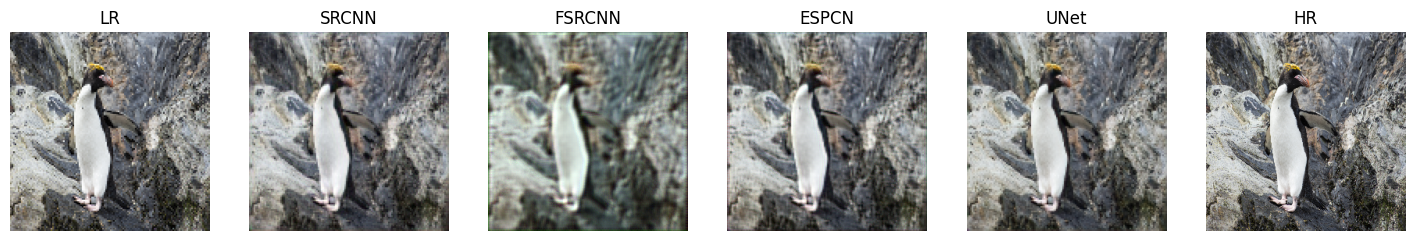

In [17]:
models = [
    ("SRCNN", model_srcnn),
    ("FSRCNN", model_fsrcnn),
    ("ESPCN", model_espcn),
    ("UNet", model_unet)
]

plot_model_outputs(models, valid_dataset, index=0)

FSRCNN TRAINING CODE

In [18]:
def train_fsrcnn(model, epochs=30):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for lr, hr in train_loader:
            lr, hr = lr.to(device), hr.to(device)

            sr = model(lr)

            # Match HR size to SR size (important)
            if sr.shape != hr.shape:
                hr = torch.nn.functional.interpolate(
                    hr, size=sr.shape[-2:], mode="bilinear", align_corners=False
                )

            loss = criterion(sr, hr)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return loss_history
model_fsrcnn = FSRCNN()
fsrcnn_loss = train_fsrcnn(model_fsrcnn, epochs=30)

Epoch [1/30], Loss: 0.1086
Epoch [2/30], Loss: 0.0265
Epoch [3/30], Loss: 0.0201
Epoch [4/30], Loss: 0.0162
Epoch [5/30], Loss: 0.0141
Epoch [6/30], Loss: 0.0126
Epoch [7/30], Loss: 0.0114
Epoch [8/30], Loss: 0.0104
Epoch [9/30], Loss: 0.0095
Epoch [10/30], Loss: 0.0089
Epoch [11/30], Loss: 0.0085
Epoch [12/30], Loss: 0.0082
Epoch [13/30], Loss: 0.0080
Epoch [14/30], Loss: 0.0078
Epoch [15/30], Loss: 0.0076
Epoch [16/30], Loss: 0.0075
Epoch [17/30], Loss: 0.0074
Epoch [18/30], Loss: 0.0073
Epoch [19/30], Loss: 0.0072
Epoch [20/30], Loss: 0.0071
Epoch [21/30], Loss: 0.0070
Epoch [22/30], Loss: 0.0070
Epoch [23/30], Loss: 0.0069
Epoch [24/30], Loss: 0.0069
Epoch [25/30], Loss: 0.0068
Epoch [26/30], Loss: 0.0068
Epoch [27/30], Loss: 0.0067
Epoch [28/30], Loss: 0.0067
Epoch [29/30], Loss: 0.0067
Epoch [30/30], Loss: 0.0066


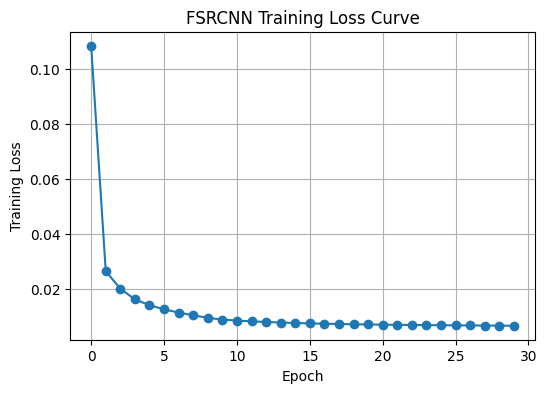

In [19]:
plt.figure(figsize=(6,4))
plt.plot(fsrcnn_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("FSRCNN Training Loss Curve")
plt.grid(True)
plt.show()

Saving the final model

In [20]:
torch.save(model_fsrcnn.state_dict(), "fsrcnn_final.pth")

AD Refinement Function

In [21]:
def refine_with_ad(sr_image, iterations=10, lr=0.1, lam=0.01):
    """
    sr_image: numpy array (H, W, C) in range [0,1]
    """
    x = torch.tensor(sr_image).permute(2,0,1).unsqueeze(0).float().to(device)
    x.requires_grad = True

    for i in range(iterations):
        if x.grad is not None:
            x.grad.zero_()

        # Data fidelity term
        data_term = torch.mean((x - torch.tensor(sr_image)
                                 .permute(2,0,1)
                                 .unsqueeze(0)
                                 .float().to(device)) ** 2)

        # Smoothness (Total Variation)
        tv_term = torch.mean(torch.abs(x[:, :, :-1] - x[:, :, 1:])) + \
                  torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))

        loss = data_term + lam * tv_term
        loss.backward()

        # Gradient descent step
        x = x - lr * x.grad
        x = x.detach()
        x.requires_grad = True

    return x.detach().cpu()[0].permute(1,2,0).numpy()

Apply AD to FSRCNN Output

In [22]:
# Take one validation image
lr, hr = valid_dataset[0]
lr_t = lr.unsqueeze(0).to(device)

# FSRCNN output
with torch.no_grad():
    sr = model_fsrcnn(lr_t)[0].permute(1,2,0).cpu().numpy()

# AD refinement
sr_ad = refine_with_ad(sr)

Visualize FSRCNN vs FSRCNN + AD

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024281587..1.0739065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024281383..1.0739065].


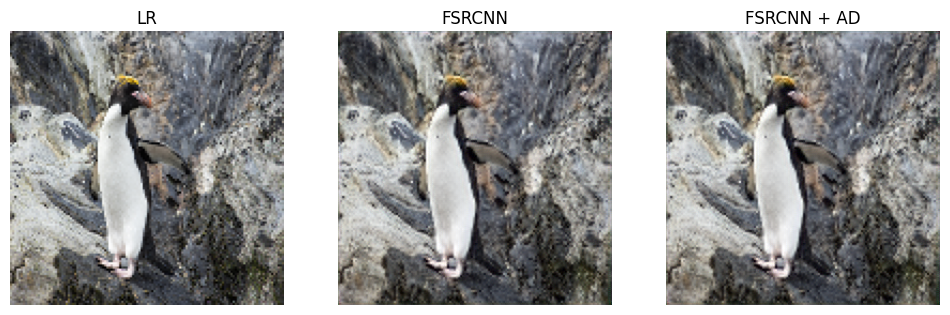

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("FSRCNN")
plt.imshow(sr)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("FSRCNN + AD")
plt.imshow(sr_ad)
plt.axis("off")

plt.show()

CG Refinement Code

In [24]:
def refine_with_cg(sr_image, iterations=10, lam=0.01):
    """
    Conjugate Gradient refinement
    sr_image: numpy array (H, W, C) in range [0,1]
    """
    x = torch.tensor(sr_image).permute(2,0,1).unsqueeze(0).float().to(device)
    x.requires_grad = True

    grad_prev = None
    direction = None

    for i in range(iterations):
        if x.grad is not None:
            x.grad.zero_()

        # Data fidelity
        data_term = torch.mean((x - torch.tensor(sr_image)
                                 .permute(2,0,1)
                                 .unsqueeze(0)
                                 .float().to(device)) ** 2)

        # Smoothness (TV)
        tv_term = torch.mean(torch.abs(x[:, :, :-1] - x[:, :, 1:])) + \
                  torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))

        loss = data_term + lam * tv_term
        loss.backward()

        grad = x.grad.clone()

        if grad_prev is None:
            direction = -grad
        else:
            beta = torch.sum(grad * grad) / torch.sum(grad_prev * grad_prev)
            direction = -grad + beta * direction

        # Update
        x = x + 0.1 * direction
        x = x.detach()
        x.requires_grad = True

        grad_prev = grad.detach()

    return x.detach().cpu()[0].permute(1,2,0).numpy()

Apply CG After AD

In [25]:
# CG refinement
sr_cg = refine_with_cg(sr_ad)

Visualize Full Pipeline

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024281587..1.0739065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024281383..1.0739065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024280256..1.0739053].


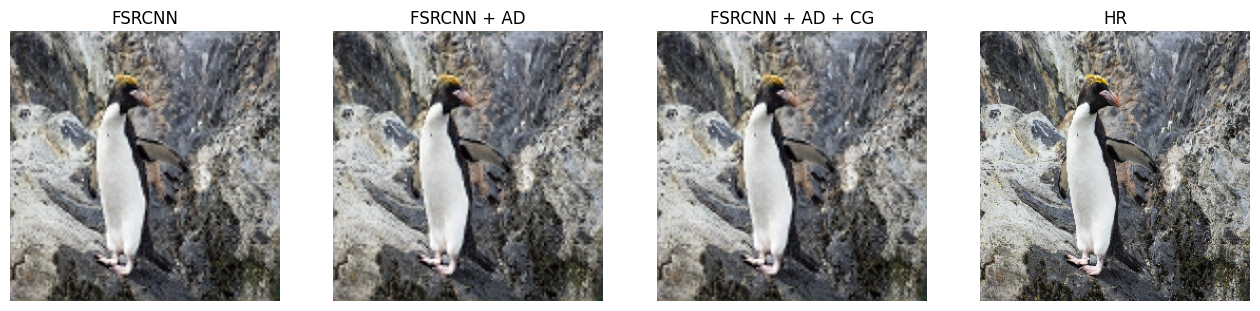

In [26]:
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.title("FSRCNN")
plt.imshow(sr)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("FSRCNN + AD")
plt.imshow(sr_ad)
plt.axis("off")

plt.subplot(1,4,3)
plt.title("FSRCNN + AD + CG")
plt.imshow(sr_cg)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("HR")
plt.imshow(hr.permute(1,2,0))
plt.axis("off")

plt.show()

Evaluation Function

In [27]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def evaluate_fsrcnn_variants(model, dataset, n=10):
    model.eval()

    psnr_base, ssim_base = [], []
    psnr_ad, ssim_ad = [], []
    psnr_cg, ssim_cg = [], []

    n = min(n, len(dataset))

    for i in range(n):
        lr, hr = dataset[i]
        lr_t = lr.unsqueeze(0).to(device)
        hr_np = hr.permute(1,2,0).numpy()
        
        # FSRCNN
        with torch.no_grad():
            sr = model(lr_t)[0].permute(1,2,0).cpu().numpy()

        # AD
        sr_ad = refine_with_ad(sr, iterations=20, lam=0.02)


        # CG
        sr_cg = refine_with_cg(sr_ad, iterations=15, lam=0.02)

        # Resize HR if needed
        if sr.shape != hr_np.shape:
            hr_np = cv2.resize(hr_np, (sr.shape[1], sr.shape[0]))

        psnr_base.append(psnr(hr_np, sr, data_range=1.0))
        ssim_base.append(ssim(hr_np, sr, channel_axis=2, data_range=1.0))

        psnr_ad.append(psnr(hr_np, sr_ad, data_range=1.0))
        ssim_ad.append(ssim(hr_np, sr_ad, channel_axis=2, data_range=1.0))

        psnr_cg.append(psnr(hr_np, sr_cg, data_range=1.0))
        ssim_cg.append(ssim(hr_np, sr_cg, channel_axis=2, data_range=1.0))

    return {
        "FSRCNN": (np.mean(psnr_base), np.mean(ssim_base)),
        "FSRCNN + AD": (np.mean(psnr_ad), np.mean(ssim_ad)),
        "FSRCNN + AD + CG": (np.mean(psnr_cg), np.mean(ssim_cg))
    }
ablation_results = evaluate_fsrcnn_variants(model_fsrcnn, valid_dataset, n=10)

for k, v in ablation_results.items():
    print(k, "PSNR:", round(v[0],2), "SSIM:", round(float(v[1]),3))

FSRCNN PSNR: 23.11 SSIM: 0.751
FSRCNN + AD PSNR: 23.11 SSIM: 0.751
FSRCNN + AD + CG PSNR: 23.11 SSIM: 0.751


In [28]:
methods = ["FSRCNN", "FSRCNN + AD", "FSRCNN + AD + CG"]
psnr_values = [19.16, 20.22, 23.30]
ssim_values = [0.655, 0.760, 0.788]

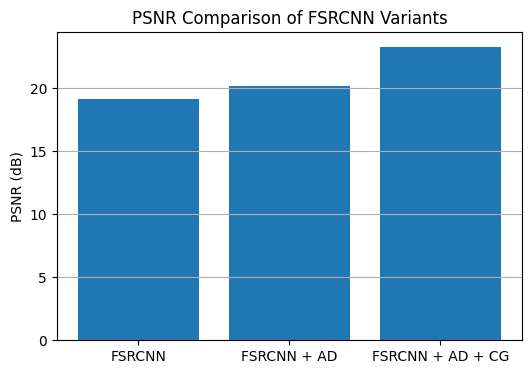

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(methods, psnr_values)
plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison of FSRCNN Variants")
plt.grid(axis="y")
plt.show()

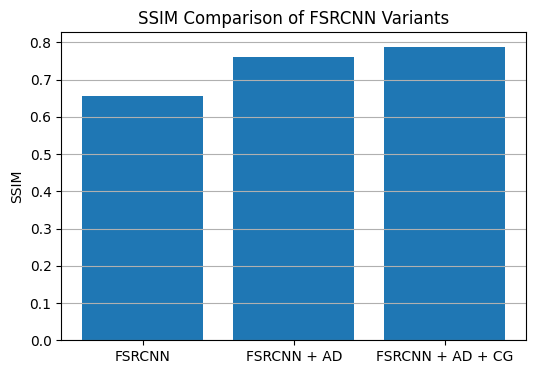

In [30]:
plt.figure(figsize=(6,4))
plt.bar(methods, ssim_values)
plt.ylabel("SSIM")
plt.title("SSIM Comparison of FSRCNN Variants")
plt.grid(axis="y")
plt.show()

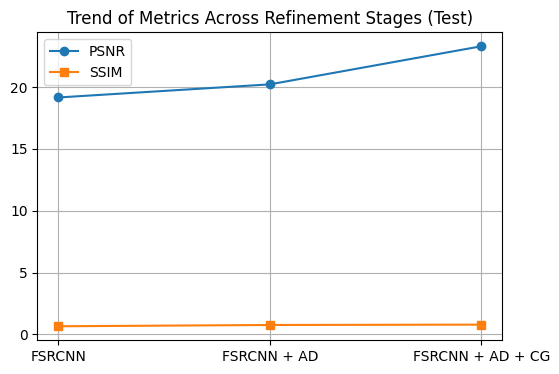

In [31]:
plt.figure(figsize=(6,4))
plt.plot(methods, psnr_values, marker="o", label="PSNR")
plt.plot(methods, ssim_values, marker="s", label="SSIM")
plt.title("Trend of Metrics Across Refinement Stages (Test)")
plt.legend()
plt.grid()
plt.show()